<a href="https://colab.research.google.com/github/GOWSALYAR7397/-shopping-mod3-link/blob/main/advance_time_series_forecasting_with_attention_based_lstm_myproject33.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# Advanced Time Series Forecasting with Attention-Based LSTMs
# Google Colab - Section 1: Setup & Imports
# ============================================================

!pip -q install yfinance prophet tqdm seaborn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import yfinance as yf
from prophet import Prophet

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

[*********************100%***********************]  1 of 1 completed

Data shape: (2515, 2)


Price,ds,y
Ticker,,^VIX
0,2015-12-08,17.600000
1,2015-12-09,19.610001
2,2015-12-10,19.340000
3,2015-12-11,24.389999
4,2015-12-14,22.730000


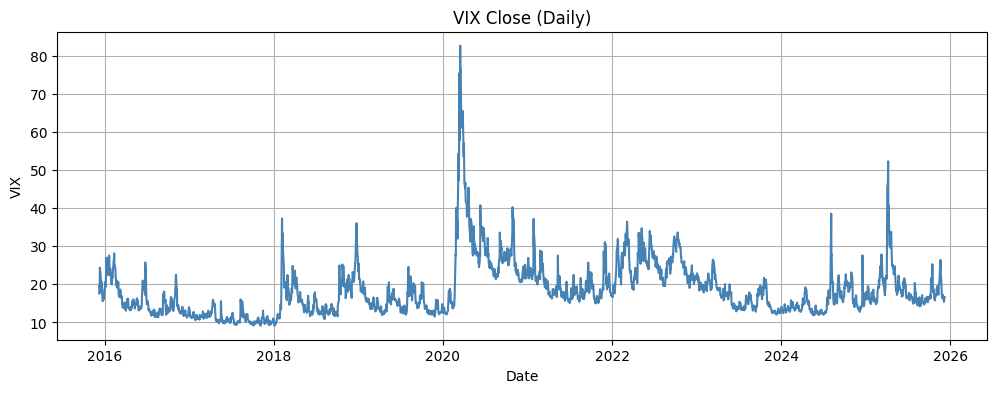

In [5]:
# ============================================================
# Section 2: Data Loading (VIX daily) & Overview
# ============================================================

symbol = "^VIX"
df = yf.download(symbol, period="10y", interval="1d")  # daily frequency
df = df[['Close']].dropna()
df.reset_index(inplace=True)
df.rename(columns={'Date': 'ds', 'Close': 'y'}, inplace=True)
df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values('ds')
print("Data shape:", df.shape)
display(df.head())

plt.figure(figsize=(12,4))
plt.plot(df['ds'], df['y'], color='steelblue')
plt.title("VIX Close (Daily)")
plt.xlabel("Date")
plt.ylabel("VIX")
plt.grid(True)
plt.show()

In [6]:
# ============================================================
# Section 3: Stationarity Check (ADF) & Differencing
# ============================================================

def adf_summary(x):
    result = adfuller(x, autolag='AIC')
    return {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Used Lag': result[2],
        'N Obs': result[3],
        'Critical Values': result[4]
    }

adf_raw = adf_summary(df['y'].values)
print("ADF (raw):", adf_raw)

use_diff = adf_raw['p-value'] > 0.05
print("Use differencing for modeling inputs:", use_diff)

if use_diff:
    df['y_diff'] = df['y'].diff()
    df_diff = df.dropna().copy()
else:
    df_diff = df.copy()

ADF (raw): {'ADF Statistic': np.float64(-5.316059224182416), 'p-value': np.float64(5.071459019504261e-06), 'Used Lag': 9, 'N Obs': 2505, 'Critical Values': {'1%': np.float64(-3.4329631791044304), '5%': np.float64(-2.8626944896608433), '10%': np.float64(-2.5673845793841457)}}
Use differencing for modeling inputs: False


In [7]:
# ============================================================
# Section 4: Train/Validation/Test Split
# ============================================================

def time_split(data, train_ratio=0.7, val_ratio=0.15):
    n = len(data)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    train = data.iloc[:train_end]
    val = data.iloc[train_end:val_end]
    test = data.iloc[val_end:]
    return train, val, test

target_col = 'y' if not use_diff else 'y_diff'
train_df, val_df, test_df = time_split(df_diff[['ds', target_col]], 0.7, 0.15)
print("Split sizes:", len(train_df), len(val_df), len(test_df))

Split sizes: 1760 377 378


In [8]:
# ============================================================
# Section 5: Scaling & Sequence Construction
# ============================================================

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_df[[target_col]])

train_df['scaled'] = scaler.transform(train_df[[target_col]])
val_df['scaled']   = scaler.transform(val_df[[target_col]])
test_df['scaled']  = scaler.transform(test_df[[target_col]])

L = 60   # input window
H = 10   # forecast horizon

def make_sequences(series, input_len=60, horizon=10):
    X, Y = [], []
    for i in range(len(series) - input_len - horizon + 1):
        X.append(series[i:i+input_len])
        Y.append(series[i+input_len:i+input_len+horizon])
    return np.array(X), np.array(Y)

X_train, Y_train = make_sequences(train_df['scaled'].values, L, H)
X_val,   Y_val   = make_sequences(val_df['scaled'].values, L, H)
X_test,  Y_test  = make_sequences(test_df['scaled'].values, L, H)

print("Train sequences:", X_train.shape, Y_train.shape)
print("Val sequences:", X_val.shape, Y_val.shape)
print("Test sequences:", X_test.shape, Y_test.shape)

X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

Train sequences: (1691, 60) (1691, 10)
Val sequences: (308, 60) (308, 10)
Test sequences: (309, 60) (309, 10)


In [9]:
# ============================================================
# Section 6: Vanilla Seq2Seq LSTM (Baseline) & Training
# ============================================================

def build_vanilla_seq2seq_lstm(input_len=60, horizon=10, units=64, dropout=0.2):
    encoder_inputs = layers.Input(shape=(input_len, 1))
    encoder_lstm = layers.LSTM(units, return_sequences=False, return_state=True, dropout=dropout)
    encoder_out, state_h, state_c = encoder_lstm(encoder_inputs)

    repeat = layers.RepeatVector(horizon)(encoder_out)
    decoder_lstm = layers.LSTM(units, return_sequences=True, dropout=dropout)
    decoder_out = decoder_lstm(repeat, initial_state=[state_h, state_c])

    outputs = layers.TimeDistributed(layers.Dense(1))(decoder_out)
    model = models.Model(encoder_inputs, outputs)
    model.compile(optimizer=optimizers.Adam(1e-3), loss='mae')
    return model

vanilla_model = build_vanilla_seq2seq_lstm(L, H, units=64, dropout=0.2)
vanilla_model.summary()

es  = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history_vanilla = vanilla_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=100,
    batch_size=64,
    callbacks=[es, rlr],
    verbose=1
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 64),      │     16,896 │ input_layer[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 10, 64)    │          0 │ lstm[0][0]        │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 10, 64)    │     33,024 │ repeat_vector[0]… │
│                     │                   │            │ lstm[0][1],       │
│                     │                   │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 10, 1)     │         65 │ lstm_1[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - loss: 0.0768 - val_loss: 0.0216 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0531 - val_loss: 0.0196 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0504 - val_loss: 0.0198 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0511 - val_loss: 0.0205 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0493 - val_loss: 0.0196 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0505 - val_loss: 0.0204 - learning_rate: 0.0010
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0519 - val_loss: 0.0188 - learning_rate: 0.0010
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0497 - val_loss: 0.0187 - learning_rate: 0.0010
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0490 - val_loss: 0.0195 - learning_rate: 0.0010
Epoch 10/1

In [10]:
# ============================================================
# Section 7: Attention Seq2Seq LSTM (Bahdanau) & Training
# ============================================================

class BahdanauAttention(layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = layers.Dense(units)
        self.W2 = layers.Dense(units)
        self.V  = layers.Dense(1)

    def call(self, encoder_outputs, hidden_state):
        # encoder_outputs: (batch, time, units)
        # hidden_state: (batch, units)
        hidden_with_time_axis = tf.expand_dims(hidden_state, 1)
        score = self.V(tf.nn.tanh(self.W1(encoder_outputs) + self.W2(hidden_with_time_axis)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = tf.reduce_sum(attention_weights * encoder_outputs, axis=1)
        return context_vector, attention_weights

def build_attention_seq2seq_lstm(input_len=60, horizon=10, units=64, dropout=0.2):
    encoder_inputs = layers.Input(shape=(input_len, 1))
    encoder_lstm = layers.LSTM(units, return_sequences=True, return_state=True, dropout=dropout)
    encoder_seq, state_h, state_c = encoder_lstm(encoder_inputs)

    attention = BahdanauAttention(units)

    # Decoder: use RepeatVector + TimeDistributed to keep it symbolic
    # We feed the context vector at each horizon step
    context_vector, _ = attention(encoder_seq, state_h)
    repeat_context = layers.RepeatVector(horizon)(context_vector)
    decoder_lstm = layers.LSTM(units, return_sequences=True, dropout=dropout)
    decoder_out = decoder_lstm(repeat_context, initial_state=[state_h, state_c])
    outputs = layers.TimeDistributed(layers.Dense(1))(decoder_out)

    model = models.Model(encoder_inputs, outputs)
    model.compile(optimizer=optimizers.Adam(1e-3), loss='mae')
    return model

attn_model = build_attention_seq2seq_lstm(L, H, units=64, dropout=0.2)
attn_model.summary()

es  = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history_attn = attn_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=100,
    batch_size=64,
    callbacks=[es, rlr],
    verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 60, 64),  │     16,896 │ input_layer_1[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention  │ [(None, 64),      │      8,385 │ lstm_2[0][0],     │
│ (BahdanauAttention) │ (None, 60, 1)]    │            │ lstm_2[0][1]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 10, 64)    │          0 │ bahdanau_attenti… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 10, 64)    │     33,024 │ repeat_vector_1[… │
│                     │                   │            │ lstm_2[0][1],     │
│                     │                   │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 10, 1)     │         65 │ lstm_3[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,370 (228.01 KB)

 Trainable params: 58,370 (228.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0842 - val_loss: 0.0243 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0549 - val_loss: 0.0209 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0515 - val_loss: 0.0198 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0501 - val_loss: 0.0205 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0518 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0481 - val_loss: 0.0192 - learning_rate: 0.0010
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0514 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0463 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0506 - val_loss: 0.0189 - learning_rate: 0.0010
Epoch 10/1

In [11]:
# ============================================================
# Section 8: Attention Weights Export & Extraction
# ============================================================

# Reuse the BahdanauAttention layer we defined earlier

class AttentionSeq2SeqExport(tf.keras.Model):
    def __init__(self, units, horizon):
        super().__init__()
        self.units = units
        self.horizon = horizon
        # Encoder
        self.encoder_lstm = layers.LSTM(units, return_sequences=True, return_state=True)
        # Attention
        self.attention = BahdanauAttention(units)
        # Decoder
        self.decoder_lstm = layers.LSTM(units, return_state=True)
        self.fc = layers.Dense(1)

    def call(self, inputs):
        # Encode
        encoder_seq, state_h, state_c = self.encoder_lstm(inputs)
        decoder_state_h, decoder_state_c = state_h, state_c

        outputs, alphas = [], []
        for _ in range(self.horizon):
            # Attention over encoder outputs
            context_vector, alpha = self.attention(encoder_seq, decoder_state_h)
            context_vector_exp = tf.expand_dims(context_vector, 1)
            # One‑step decode
            out, decoder_state_h, decoder_state_c = self.decoder_lstm(
                context_vector_exp, initial_state=[decoder_state_h, decoder_state_c]
            )
            step_out = self.fc(out)
            outputs.append(step_out)
            alphas.append(alpha)

        # Stack outputs and alphas
        outputs = tf.stack(outputs, axis=1)   # (batch, H, 1)
        alphas  = tf.stack(alphas, axis=1)    # (batch, H, L, 1)
        return outputs, alphas

# Build export model (same units/horizon as training)
attn_export = AttentionSeq2SeqExport(units=64, horizon=H)

# Example run on test batch to get predictions + attention weights
preds_attn, alphas = attn_export(X_test[:32])  # eager execution, no KerasTensor error
print("Preds shape:", preds_attn.shape)   # (batch, H, 1)
print("Alphas shape:", alphas.shape)      # (batch, H, L, 1)


Preds shape: (32, 10, 1)
Alphas shape: (32, 10, 60, 1)


In [12]:
# ============================================================
# Section 9: Inverse Scaling, Reconstruction & Metrics (Fixed)
# ============================================================

def inverse_scale_preds(pred_scaled, scaler):
    """Inverse transform predictions (3D: batch,horizon,1)."""
    b, h, c = pred_scaled.shape
    flat = pred_scaled.reshape(-1, 1)
    inv = scaler.inverse_transform(flat).reshape(b, h, c)
    return inv

def inverse_scale_truth(y_scaled, scaler):
    """Inverse transform ground truth (2D: batch,horizon)."""
    b, h = y_scaled.shape
    flat = y_scaled.reshape(-1, 1)
    inv = scaler.inverse_transform(flat).reshape(b, h, 1)
    return inv

# --- Inverse scaling ---
Y_test_inv = inverse_scale_truth(Y_test, scaler)

pred_attn_scaled    = attn_model.predict(X_test, verbose=0)
pred_vanilla_scaled = vanilla_model.predict(X_test, verbose=0)

pred_attn_inv    = inverse_scale_preds(pred_attn_scaled, scaler)
pred_vanilla_inv = inverse_scale_preds(pred_vanilla_scaled, scaler)

# --- If differencing was applied, reconstruct forecasts ---
if use_diff:
    orig_test_segment = df.iloc[len(df) - len(test_df) - (L+H-1) : ]
    base_series = orig_test_segment['y'].values
    last_levels = []
    for i in range(len(base_series) - L - H + 1):
        last_levels.append(base_series[i+L-1])
    last_levels = np.array(last_levels)[..., np.newaxis]

    pred_attn_inv    = reconstruct_from_diff(last_levels, pred_attn_inv)
    pred_vanilla_inv = reconstruct_from_diff(last_levels, pred_vanilla_inv)
    Y_test_inv       = reconstruct_from_diff(last_levels, Y_test_inv)

# --- Metrics computation ---
def metrics_over_horizon(y_true, y_pred, H):
    maes, rmses, mapes = [], [], []
    for t in range(H):
        yt = y_true[:, t, 0]
        yp = y_pred[:, t, 0]
        mae  = mean_absolute_error(yt, yp)
        rmse = np.sqrt(mean_squared_error(yt, yp))
        mape = np.mean(np.abs((yt - yp) / (yt + 1e-8))) * 100
        maes.append(mae); rmses.append(rmse); mapes.append(mape)
    return np.array(maes), np.array(rmses), np.array(mapes)

mae_attn, rmse_attn, mape_attn = metrics_over_horizon(Y_test_inv, pred_attn_inv, H)
mae_van,  rmse_van,  mape_van  = metrics_over_horizon(Y_test_inv, pred_vanilla_inv, H)

print("Attention-LSTM -> MAE(mean):", mae_attn.mean(),
      "RMSE(mean):", rmse_attn.mean(),
      "MAPE(mean%):", mape_attn.mean())

print("Vanilla-LSTM  -> MAE(mean):", mae_van.mean(),
      "RMSE(mean):", rmse_van.mean(),
      "MAPE(mean%):", mape_van.mean())

Attention-LSTM -> MAE(mean): 2.6722590458817463 RMSE(mean): 4.675114073437381 MAPE(mean%): 12.123590844203122
Vanilla-LSTM  -> MAE(mean): 2.574989795067549 RMSE(mean): 4.483032915912457 MAPE(mean%): 11.792663094559359


Prophet -> MAE: 13.820615255838472 RMSE: 15.102426677427722 MAPE(%): 74.15254960088717


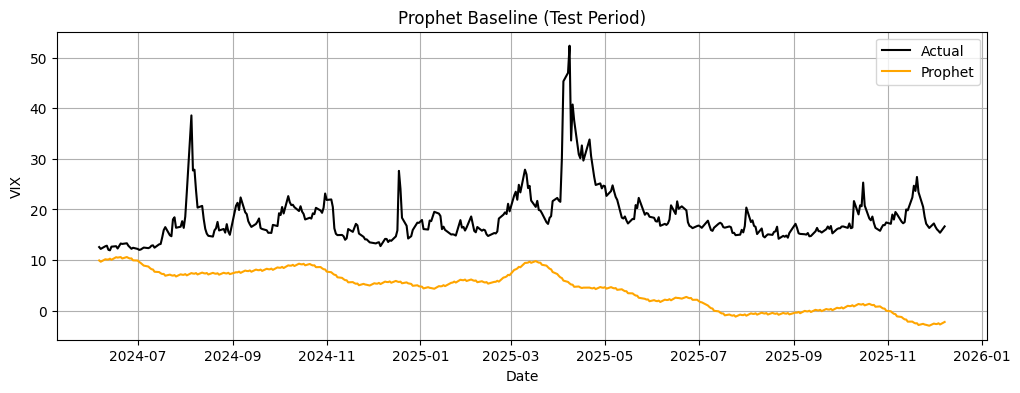

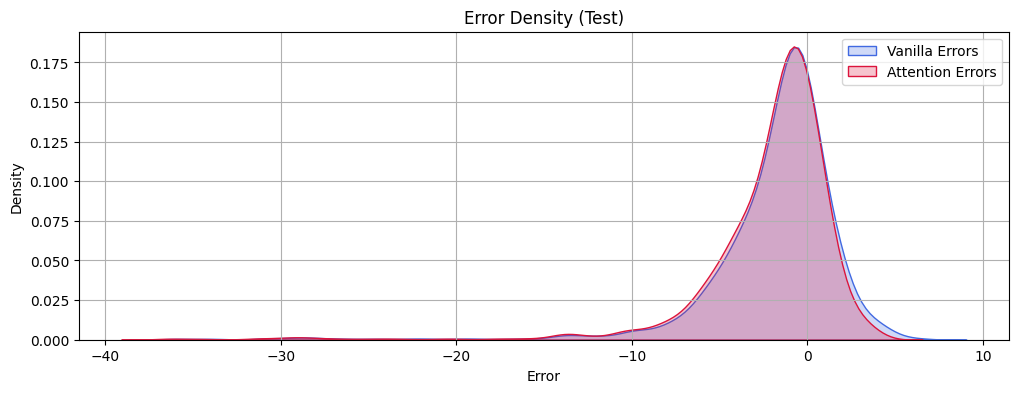

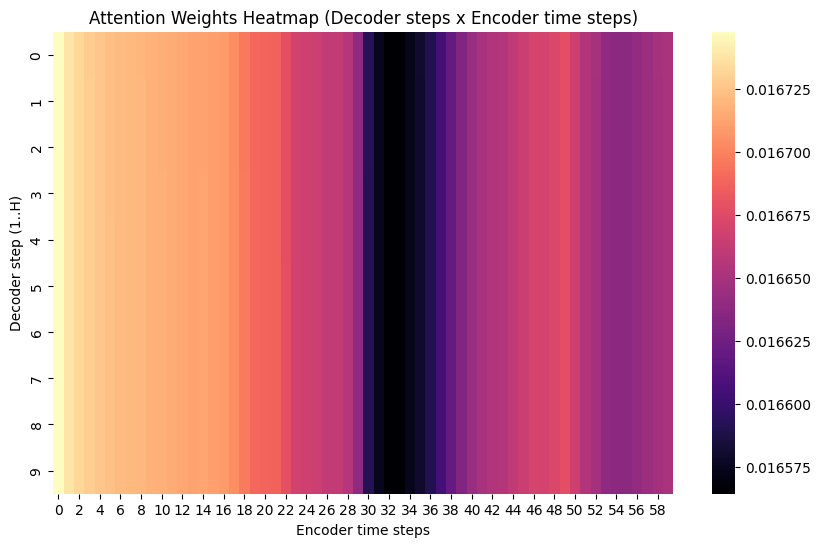

In [13]:
# ============================================================
# Section 10: Prophet Baseline & Visualizations
# ============================================================

# Prophet expects columns: ds (datetime), y (float)
train_end = len(train_df) + len(val_df)

prophet_train = pd.DataFrame({
    "ds": pd.to_datetime(df["ds"].iloc[:train_end]),
    "y":  df["y"].iloc[:train_end].astype(float).squeeze()
})

prophet_test = pd.DataFrame({
    "ds": pd.to_datetime(df["ds"].iloc[train_end:]),
    "y":  df["y"].iloc[train_end:].astype(float).squeeze()
})

# Drop NaNs just in case
prophet_train = prophet_train.dropna()
prophet_test  = prophet_test.dropna()

# Fit Prophet
m = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
m.fit(prophet_train)

# Forecast on test period
future = prophet_test[["ds"]].copy()
forecast = m.predict(future)
prophet_pred = forecast["yhat"].values
prophet_true = prophet_test["y"].values

# Metrics
mae_prophet  = mean_absolute_error(prophet_true, prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(prophet_true, prophet_pred))
mape_prophet = np.mean(np.abs((prophet_true - prophet_pred) / (prophet_true + 1e-8))) * 100

print("Prophet -> MAE:", mae_prophet,
      "RMSE:", rmse_prophet,
      "MAPE(%):", mape_prophet)

# --- Prophet forecast vs actual (test period) ---
plt.figure(figsize=(12,4))
plt.plot(prophet_test['ds'], prophet_true, label='Actual', color='black')
plt.plot(prophet_test['ds'], prophet_pred, label='Prophet', color='orange')
plt.title("Prophet Baseline (Test Period)")
plt.xlabel("Date")
plt.ylabel("VIX")
plt.legend()
plt.grid(True)
plt.show()

# --- Error density comparison (Vanilla vs Attention) ---
err_van = (pred_vanilla_inv[:,:,0] - Y_test_inv[:,:,0]).flatten()
err_att = (pred_attn_inv[:,:,0] - Y_test_inv[:,:,0]).flatten()

plt.figure(figsize=(12,4))
sns.kdeplot(err_van, label='Vanilla Errors', fill=True, color='royalblue')
sns.kdeplot(err_att, label='Attention Errors', fill=True, color='crimson')
plt.title("Error Density (Test)")
plt.xlabel("Error")
plt.legend()
plt.grid(True)
plt.show()

# --- Attention heatmap (H x L) ---
idx = 10   # choose a test sample index
preds_attn_one, alphas_one = attn_export(X_test[idx:idx+1])
attn_matrix = alphas_one.numpy().squeeze()

# Ensure shape is (H, L)
if attn_matrix.ndim == 3 and attn_matrix.shape[-1] == 1:
    attn_matrix = attn_matrix[...,0]  # (H, L)

plt.figure(figsize=(10,6))
sns.heatmap(attn_matrix, cmap='magma', cbar=True)
plt.title("Attention Weights Heatmap (Decoder steps x Encoder time steps)")
plt.xlabel("Encoder time steps")
plt.ylabel("Decoder step (1..H)")
plt.show()